In [2]:
!brew install libomp

==> Auto-updating Homebrew...
Adjust how often this is run with HOMEBREW_AUTO_UPDATE_SECS or disable with
HOMEBREW_NO_AUTO_UPDATE. Hide these hints with HOMEBREW_NO_ENV_HINTS (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/portable-ruby/portable-ruby/blobs/sha256:20fa657858e44a4b39171d6e4111f8a9716eb62a78ebbd1491d94f90bb7b830a
######################################################################### 100.0%                               23.4%           38.0%  53.8%#############################             85.5%
==> Pouring portable-ruby-3.4.5.arm64_big_sur.bottle.tar.gz
==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
act_runner: Action runner for Gitea based on Gitea's fork of act
addlicense: Scan directories recursively to ensure source files have license headers
aiac: Artificial Intelligence Infrastructure-as-Code Generator
aiken: Modern smart contract platform for Cardano
air: Fast and opinionated formatter for R code
anchor

In [ ]:
import os
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns



from eyf.clase_ternaria import calcular_clase_ternaria

# Read Data

In [10]:
# Definir rutas
DATA_PATH = '../data'
RAW_DATA_NAME = 'competencia_01_crudo.csv'
RAW_DATA_PATH = f'{DATA_PATH}/{RAW_DATA_NAME}'
TARGET_DATA_NAME = 'competencia_01_target.csv'
TARGET_DATA_PATH = f'{DATA_PATH}/{TARGET_DATA_NAME}'


In [ ]:
if not os.path.exists(TARGET_DATA_PATH):
    print("No existe el archivo de target, calculando...")
    # Cargar los datos
    print("Cargando datos...")
    df = pd.read_csv(RAW_DATA_PATH)
    print(f"Datos cargados: {df.shape[0]} filas y {df.shape[1]} columnas")

    # Calcular la clase ternaria (variable objetivo)
    print("Calculando clase ternaria...")
    df = calcular_clase_ternaria(df)

    # Verificar la distribución de clases
    print("\nDistribución de la clase ternaria:")
    print(df['clase_ternaria'].value_counts())
    print("\nPorcentajes:")
    print(df['clase_ternaria'].value_counts(normalize=True) * 100)
    df.to_csv(f'{DATA_PATH}/competencia_01_target.csv', index=False)
else:
    print("Existe el archivo de target, cargando...")
    df = pd.read_csv(TARGET_DATA_PATH)


## Data types

In [31]:
categorical_features = ["Master_status", "Visa_status", "clase_ternaria"]
df[categorical_features] = df[categorical_features].astype('category')


## Clase Binaria

In [32]:
# Crear variable target binaria: BAJA+2 (1) vs resto (0)
print("Creando variable target binaria...")
df['target_binario'] = (df['clase_ternaria'] == 'BAJA+2').astype(int)

print("Distribución del target binario:")
print(df['target_binario'].value_counts())
print("\nPorcentajes:")
print(df['target_binario'].value_counts(normalize=True) * 100)

# Verificar distribución por foto_mes
print(f"\nMeses disponibles: {sorted(df['foto_mes'].unique())}")
print(f"\nDistribución de target por foto_mes:")
print(df.groupby('foto_mes')['target_binario'].agg(['count', 'sum', 'mean']))


Creando variable target binaria...
Distribución del target binario:
target_binario
0    974501
1      3938
Name: count, dtype: int64

Porcentajes:
target_binario
0    99.597522
1     0.402478
Name: proportion, dtype: float64

Meses disponibles: [np.int64(202101), np.int64(202102), np.int64(202103), np.int64(202104), np.int64(202105), np.int64(202106)]

Distribución de target por foto_mes:
           count   sum      mean
foto_mes                        
202101    161527   825  0.005108
202102    162155  1032  0.006364
202103    163109   951  0.005830
202104    163418  1130  0.006915
202105    163917     0  0.000000
202106    164313     0  0.000000


## Pesos

In [48]:
df['clase_peso'] = 1.0

df.loc[df['clase_ternaria'] == 'BAJA+2', 'clase_peso'] = 1.00002
df.loc[df['clase_ternaria'] == 'BAJA+1', 'clase_peso'] = 1.00001

# Train a basic LightGBM

In [50]:
# Filtrar datos por foto_mes específicos
print("Filtrando datos por foto_mes...")

# Train: foto_mes < 202104
train_data = df[df['foto_mes'].isin([202102, 202103])].copy()
print(f"Datos de entrenamiento (< 202104): {train_data.shape[0]} registros")
print(f"Target positivos en train: {train_data['target_binario'].sum()} ({train_data['target_binario'].mean()*100:.3f}%)")
w_train = train_data['clase_peso']

# Test: foto_mes = 202104
test_data = df[df['foto_mes'] == 202104].copy()
print(f"Datos de evaluación (202104): {test_data.shape[0]} registros")
print(f"Target positivos en test: {test_data['target_binario'].sum()} ({test_data['target_binario'].mean()*100:.3f}%)")
w_test = test_data['clase_peso']
# Verificar que tenemos ambos meses
if train_data.empty:
    print("⚠️  ADVERTENCIA: No hay datos para foto_mes = 202103")
if test_data.empty:
    print("⚠️  ADVERTENCIA: No hay datos para foto_mes = 202104")


Filtrando datos por foto_mes...
Datos de entrenamiento (< 202104): 325264 registros
Target positivos en train: 1983 (0.610%)
Datos de evaluación (202104): 163418 registros
Target positivos en test: 1130 (0.691%)


In [51]:
# Preparar features (permitiendo valores nulos)
print("Preparando features...")

# Definir columnas a excluir
exclude_cols = ['numero_de_cliente', 'foto_mes', 'clase_ternaria', 'target_binario', 'clase_peso']
feature_cols = [col for col in train_data.columns if col not in exclude_cols]

print(f"Total de features disponibles: {len(feature_cols)}")

# Separar X e y para train
X_train = train_data[feature_cols]
y_train = train_data['target_binario']

# Separar X e y para test
X_test = test_data[feature_cols]
y_test = test_data['target_binario']

print(f"Shape X_train: {X_train.shape}")
print(f"Shape X_test: {X_test.shape}")
print(f"Distribución y_train: {y_train.value_counts().to_dict()}")
print(f"Distribución y_test: {y_test.value_counts().to_dict()}")

Preparando features...
Total de features disponibles: 152
Shape X_train: (325264, 152)
Shape X_test: (163418, 152)
Distribución y_train: {0: 323281, 1: 1983}
Distribución y_test: {0: 162288, 1: 1130}


In [ ]:
# Entrenar LightGBM básico
print("Entrenando modelo LightGBM básico...")

ganancia_acierto = 780000
costo_estimulo = 20000

def lgb_gan_eval(y_pred, data):
    weight = data.get_weight()
    ganancia = np.where(weight == 1.00002, ganancia_acierto, 0) - np.where(weight < 1.00002, costo_estimulo, 0)
    ganancia = ganancia[np.argsort(y_pred)[::-1]]
    ganancia = np.cumsum(ganancia)

    return 'gan_eval', np.max(ganancia) , True

# Configuración simple/por defecto para LightGBM binario
params = {
    'objective': 'binary',
    'metric': 'gan_eval',
    'boosting_type': 'gbdt',
    'max_bin': 31,
    'num_leaves': 31,
    'learning_rate': 0.01,
    'feature_fraction': 0.3,
    'bagging_fraction': 0.7,
    'verbose': 0
}

# Crear datasets de LightGBM
train_dataset = lgb.Dataset(X_train, label=y_train, weight=w_train)
test_dataset = lgb.Dataset(X_test, label=y_test, reference=train_dataset, weight=w_test)

print("Iniciando entrenamiento...")
# Entrenar modelo con early stopping
model = lgb.train(
    params,
    train_dataset,
    num_boost_round=1000,
    valid_sets=[train_dataset, test_dataset],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=100)
    ],
    feval=lgb_gan_eval,
)




Entrenando modelo LightGBM básico...
Iniciando entrenamiento...
Training until validation scores don't improve for 50 rounds
[100]	train's gan_eval: 7.0828e+08	test's gan_eval: 3.3702e+08
[200]	train's gan_eval: 8.0988e+08	test's gan_eval: 3.4374e+08
[300]	train's gan_eval: 9.0778e+08	test's gan_eval: 3.4674e+08
[400]	train's gan_eval: 9.8776e+08	test's gan_eval: 3.4956e+08
Early stopping, best iteration is:
[438]	train's gan_eval: 1.013e+09	test's gan_eval: 3.5174e+08
✅ Modelo entrenado exitosamente!
Mejor iteración: 438


KeyError: 'binary_logloss'

In [55]:
print(f"✅ Modelo entrenado exitosamente!")
print(f"Mejor iteración: {model.best_iteration}")
print(f"Mejor score de validación: {model.best_score['test']['gan_eval']:.6f}")

✅ Modelo entrenado exitosamente!
Mejor iteración: 438
Mejor score de validación: 351740000.000000


In [73]:
print(f"Mejor score de validación: {model.best_score['train']['gan_eval']:.6f}")


Mejor score de validación: 1013000000.000000


In [58]:
cv_results2 = lgb.cv(
    params,
    train_dataset,
    num_boost_round=1000,
    feval=lgb_gan_eval,
    nfold=5,
    seed=42
)

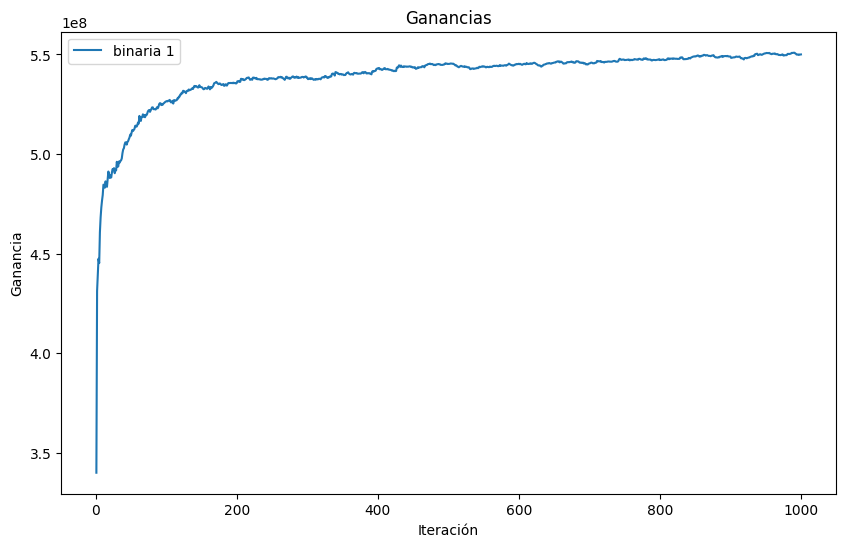

In [59]:
df_ganancias = pd.DataFrame({
    'binaria1': cv_results2['valid gan_eval-mean'],
    'Iteracion': range(1, len(cv_results2['valid gan_eval-mean']) + 1)
})

# Normalizamos la ganancias
df_ganancias['binaria1'] = df_ganancias['binaria1']*5

plt.figure(figsize=(10, 6))
sns.lineplot(x='Iteracion', y='binaria1', data=df_ganancias, label='binaria 1')
plt.title('Ganancias')
plt.xlabel('Iteración')
plt.ylabel('Ganancia')
plt.legend()
plt.show()

In [ ]:
# Evaluar ganancia del modelo en el test set
print("=== GANANCIA EN TEST SET ===")
# Calcular predicciones
y_pred_test = model.predict(X_test, num_iteration=model.best_iteration)
# Aplicar la función de ganancia existente
ganancia_test = lgb_gan_eval(y_pred_test, test_dataset)
print(f"Ganancia en test set: {ganancia_test[1]:,.0f}")



=== GANANCIA EN TEST SET ===
Ganancia en test set: 351,740,000
Evaluación: gan_eval - 351,740,000


# Optimizar hiperparámetros

In [69]:
def objective(trial):

    num_leaves = trial.suggest_int('num_leaves', 8, 100),
    learning_rate = trial.suggest_float('learning_rate', 0.005, 0.3), # mas bajo, más iteraciones necesita
    min_data_in_leaf = trial.suggest_int('min_data_in_leaf', 1, 1000),
    feature_fraction = trial.suggest_float('feature_fraction', 0.1, 1.0),
    bagging_fraction = trial.suggest_float('bagging_fraction', 0.1, 1.0),

    params = {
        'objective': 'binary',
        'metric': 'custom',
        'boosting_type': 'gbdt',
        'first_metric_only': True,
        'boost_from_average': True,
        'feature_pre_filter': False,
        'max_bin': 31,
        'num_leaves': num_leaves,
        'learning_rate': learning_rate,
        'min_data_in_leaf': min_data_in_leaf,
        'feature_fraction': feature_fraction,
        'bagging_fraction': bagging_fraction,
        'seed': 42,
        'verbose': -1,
        'num_threads':10

    }
    train_data = lgb.Dataset(X_train,
                              label=y_train, # eligir la clase
                              weight=w_train)
    cv_results = lgb.cv(
        params,
        train_data,
        num_boost_round=100, # modificar, subit y subir... y descomentar la línea inferior
        # early_stopping_rounds= int(50 + 5 / learning_rate),
        feval=lgb_gan_eval,
        stratified=True,
        nfold=5,
        seed=42,
    )
    max_gan = max(cv_results['valid gan_eval-mean'])
    best_iter = cv_results['valid gan_eval-mean'].index(max_gan) + 1

    # Guardamos cual es la mejor iteración del modelo
    trial.set_user_attr("best_iter", best_iter)

    return max_gan * 5

# Crear estudio sin storage persistente (se guardará en CSV al final)
study_name = "exp_01_lgbm"
csv_path = DATA_PATH + "optimization_lgbm_results.csv"

study = optuna.create_study(
    direction="maximize",
    study_name=study_name
)
     

[I 2025-10-01 21:13:33,447] A new study created in memory with name: exp_01_lgbm


In [70]:
# Ejecutar la optimización
print("Iniciando optimización de hiperparámetros...")
study.optimize(objective, n_trials=100)  # Ajusta el número de trials según necesites

print("Optimización completada!")
print(f"Mejor valor: {study.best_value}")
print(f"Mejores parámetros: {study.best_params}")



Iniciando optimización de hiperparámetros...


[I 2025-10-01 21:13:48,051] Trial 0 finished with value: 523660000.0 and parameters: {'num_leaves': 81, 'learning_rate': 0.11942460497964685, 'min_data_in_leaf': 709, 'feature_fraction': 0.9205037384171744, 'bagging_fraction': 0.48056764114527867}. Best is trial 0 with value: 523660000.0.
[I 2025-10-01 21:14:00,245] Trial 1 finished with value: 544800000.0 and parameters: {'num_leaves': 50, 'learning_rate': 0.00808642566029826, 'min_data_in_leaf': 852, 'feature_fraction': 0.5412614370585251, 'bagging_fraction': 0.2861191811368227}. Best is trial 1 with value: 544800000.0.
[I 2025-10-01 21:14:05,649] Trial 2 finished with value: 531840000.0 and parameters: {'num_leaves': 9, 'learning_rate': 0.1821112493855261, 'min_data_in_leaf': 941, 'feature_fraction': 0.7230453680551647, 'bagging_fraction': 0.9984214550513129}. Best is trial 1 with value: 544800000.0.
[I 2025-10-01 21:14:18,709] Trial 3 finished with value: 418300000.0 and parameters: {'num_leaves': 69, 'learning_rate': 0.26608074294

Optimización completada!
Mejor valor: 561180000.0
Mejores parámetros: {'num_leaves': 43, 'learning_rate': 0.08031367945895283, 'min_data_in_leaf': 556, 'feature_fraction': 0.834250835748799, 'bagging_fraction': 0.20020466369951345}


In [71]:
# Guardar resultados en CSV
print(f"Guardando resultados en: {csv_path}")

# Crear DataFrame con todos los trials
trials_data = []
for trial in study.trials:
    trial_data = {
        'trial_number': trial.number,
        'value': trial.value,
        'state': trial.state.name,
        'datetime_start': trial.datetime_start,
        'datetime_complete': trial.datetime_complete,
        'duration': (trial.datetime_complete - trial.datetime_start).total_seconds() if trial.datetime_complete and trial.datetime_start else None
    }
    
    # Agregar parámetros
    for param_name, param_value in trial.params.items():
        trial_data[f'param_{param_name}'] = param_value
    
    # Agregar user attributes (como best_iter)
    for attr_name, attr_value in trial.user_attrs.items():
        trial_data[f'user_attr_{attr_name}'] = attr_value
    
    trials_data.append(trial_data)

# Convertir a DataFrame y guardar
df_results = pd.DataFrame(trials_data)
df_results.to_csv(csv_path, index=False)

print(f"✅ Resultados guardados exitosamente en {csv_path}")
print(f"Total de trials: {len(df_results)}")

# Mostrar un resumen
print("\n=== RESUMEN DE OPTIMIZACIÓN ===")
print(f"Mejor trial: {study.best_trial.number}")
print(f"Mejor valor: {study.best_value:.6f}")
print("Mejores parámetros:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("================================")


Guardando resultados en: ../dataoptimization_lgbm_results.csv
✅ Resultados guardados exitosamente en ../dataoptimization_lgbm_results.csv
Total de trials: 100

=== RESUMEN DE OPTIMIZACIÓN ===
Mejor trial: 37
Mejor valor: 561180000.000000
Mejores parámetros:
  num_leaves: 43
  learning_rate: 0.08031367945895283
  min_data_in_leaf: 556
  feature_fraction: 0.834250835748799
  bagging_fraction: 0.20020466369951345


In [72]:
optuna.visualization.plot_optimization_history(study)

ImportError: Tried to import 'plotly' but failed. Please make sure that the package is installed correctly to use this feature. Actual error: No module named 'plotly'.